# University Student Outcome Prediction with Selective Classification

This project develops a multiclass supervised-learning system that predicts whether a university student will:

- Drop out
- Remain enrolled
- Graduate

Three models are compared according to when their information becomes available:

1. Enrollment-only information
2. Enrollment plus first-semester performance
3. Enrollment plus first- and second-semester performance

The project also implements selective classification. When the model's confidence is below a validation-selected threshold, it defers the case for human review rather than forcing a potentially unreliable prediction.

The purpose is to explore how predictive performance changes as academic information becomes available and whether uncertainty-based deferral can concentrate model errors into a smaller review group.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42
CLASS_ORDER = ["Dropout", "Enrolled", "Graduate"]

sns.set_theme(style="whitegrid")

## 1. Dataset

Each row represents one university student.

The predictors contain:

- application information;
- previous qualifications;
- admission grade;
- demographic information;
- financial status;
- macroeconomic conditions;
- first-semester academic performance;
- second-semester academic performance.

The target describes the student's outcome at the end of the normal course duration.

The three classes are imbalanced, so accuracy alone is not sufficient. Balanced accuracy, macro F1-score and per-class recall are also evaluated.

In [2]:
DATA_URL = (
    "https://archive.ics.uci.edu/static/public/697/"
    "predict%2Bstudents%2Bdropout%2Band%2Bacademic%2Bsuccess.zip"
)

raw_df = pd.read_csv(
    DATA_URL,
    compression="zip",
    sep=";"
)

print("Dataset shape:", raw_df.shape)
raw_df.head()

Dataset shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df = raw_df.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(
        r"[^a-z0-9]+",
        "_",
        regex=True
    )
    .str.strip("_")
)

print(df.columns.tolist())

['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mother_s_qualification', 'father_s_qualification', 'mother_s_occupation', 'father_s_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp', 'target']


In [4]:
data_summary = pd.Series({
    "observations": len(df),
    "features": df.shape[1] - 1,
    "missing_values": df.isna().sum().sum(),
    "duplicate_rows": df.duplicated().sum(),
    "target_classes": df["target"].nunique()
})

data_summary

observations      4424
features            36
missing_values       0
duplicate_rows       0
target_classes       3
dtype: int64

In [5]:
class_distribution = (
    df["target"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .to_frame("observations")
)

class_distribution["percentage"] = (
    100
    * class_distribution["observations"]
    / len(df)
)

class_distribution.round(2)

,observations,percentage
target,,
Dropout,1421,32.12
Enrolled,794,17.95
Graduate,2209,49.93


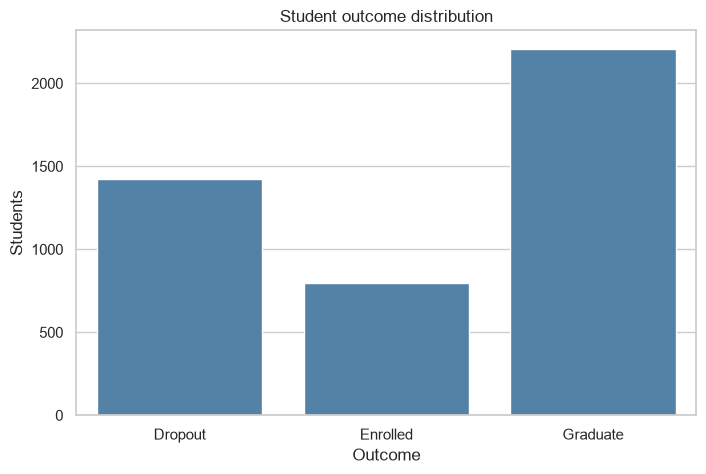

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="target",
    order=CLASS_ORDER,
    color="steelblue"
)

plt.title("Student outcome distribution")
plt.xlabel("Outcome")
plt.ylabel("Students")
plt.show()

In [7]:
df["first_sem_approval_rate"] = np.where(
    df["curricular_units_1st_sem_enrolled"] > 0,
    (
        df["curricular_units_1st_sem_approved"]
        / df["curricular_units_1st_sem_enrolled"]
    ),
    0
)

df["second_sem_approval_rate"] = np.where(
    df["curricular_units_2nd_sem_enrolled"] > 0,
    (
        df["curricular_units_2nd_sem_approved"]
        / df["curricular_units_2nd_sem_enrolled"]
    ),
    0
)

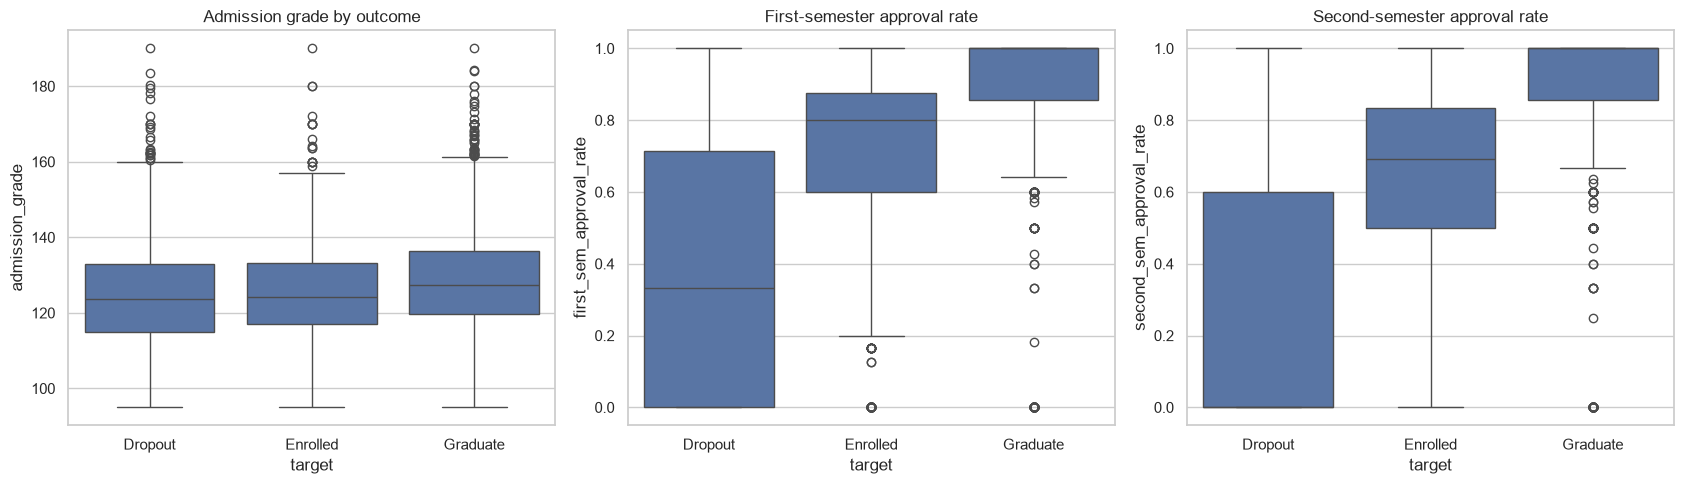

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(
    data=df,
    x="target",
    y="admission_grade",
    order=CLASS_ORDER,
    ax=axes[0]
)
axes[0].set_title("Admission grade by outcome")

sns.boxplot(
    data=df,
    x="target",
    y="first_sem_approval_rate",
    order=CLASS_ORDER,
    ax=axes[1]
)
axes[1].set_title("First-semester approval rate")

sns.boxplot(
    data=df,
    x="target",
    y="second_sem_approval_rate",
    order=CLASS_ORDER,
    ax=axes[2]
)
axes[2].set_title("Second-semester approval rate")

plt.tight_layout()
plt.show()

In [9]:
financial_outcomes = (
    df.groupby(
        [
            "tuition_fees_up_to_date",
            "debtor"
        ]
    )["target"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

financial_outcomes["percentage"] = (
    100 * financial_outcomes["proportion"]
)

financial_outcomes.round(2)

,tuition_fees_up_to_date,debtor,target,proportion,percentage
0,0,0,Dropout,0.86,85.82
1,0,0,Enrolled,0.08,7.80
2,0,0,Graduate,0.06,6.38
3,0,1,Dropout,0.87,87.40
4,0,1,Enrolled,0.08,8.13
5,0,1,Graduate,0.04,4.47
6,1,0,Graduate,0.57,57.43
7,1,0,Dropout,0.24,23.83
8,1,0,Enrolled,0.19,18.74
9,1,1,Dropout,0.38,37.74


## Exploratory findings

- Total students: **4,424**
- Original predictors: **36**
- Missing values: **0**
- Duplicate rows: **0**

Two additional predictors—first- and second-semester approval rates—were engineered later in the analysis.

### Outcome distribution

- Dropout: **1,421 students (32.12%)**
- Enrolled: **794 students (17.95%)**
- Graduate: **2,209 students (49.93%)**

The target is **moderately imbalanced**. Almost half of the students graduated, while the Enrolled class represents fewer than one-fifth of the observations. Therefore, accuracy alone could hide weak performance on the smaller Enrolled class.

Admission grades differed only modestly across the outcomes. Graduates had a slightly higher median admission grade, but the distributions overlapped substantially. Admission grade alone is therefore unlikely to separate the three outcomes reliably.

Semester approval rates showed much stronger differences. Dropouts generally approved a smaller proportion of their enrolled units, Enrolled students had intermediate approval rates, and Graduates typically had the highest approval rates. The separation became especially clear after the second semester.

Financial status was also associated with student outcomes. Among students whose tuition fees were not current, approximately **85.82% to 87.40%** dropped out, depending on debtor status. Among students with current tuition fees and no debt, only **23.83%** dropped out and **57.43%** graduated. For students whose fees were current but who were debtors, the dropout rate was **37.74%**.

These exploratory relationships are associations. They do not prove that financial or academic characteristics caused a student to drop out.

## 2. Information-availability stages

Three feature sets are created.

### Enrollment only

Uses information available when the student enters the institution. This model offers the earliest possible prediction but has limited academic-performance evidence.

### After the first semester

Adds first-semester enrollment, evaluation, approval and grade information. It can support intervention after one semester.

### After the second semester

Adds second-semester performance. It should provide stronger predictions but produces later warnings.

Comparing these stages demonstrates the trade-off between early intervention and predictive performance.

In [10]:
first_semester_features = [
    column
    for column in df.columns
    if column.startswith(
        "curricular_units_1st_sem"
    )
]

first_semester_features.append(
    "first_sem_approval_rate"
)

second_semester_features = [
    column
    for column in df.columns
    if column.startswith(
        "curricular_units_2nd_sem"
    )
]

second_semester_features.append(
    "second_sem_approval_rate"
)

semester_features = (
    first_semester_features
    + second_semester_features
)

enrollment_features = [
    column
    for column in df.columns
    if column != "target"
    and column not in semester_features
]

feature_sets = {
    "Enrollment only":
        enrollment_features,

    "After first semester":
        enrollment_features
        + first_semester_features,

    "After second semester":
        enrollment_features
        + first_semester_features
        + second_semester_features
}

for name, features in feature_sets.items():
    print(name, ":", len(features), "features")

Enrollment only : 24 features
After first semester : 31 features
After second semester : 38 features


In [11]:
categorical_candidates = [
    "marital_status",
    "application_mode",
    "course",
    "daytime_evening_attendance",
    "previous_qualification",
    "nacionality",
    "mother_s_qualification",
    "father_s_qualification",
    "mother_s_occupation",
    "father_s_occupation",
    "displaced",
    "educational_special_needs",
    "debtor",
    "tuition_fees_up_to_date",
    "gender",
    "scholarship_holder",
    "international"
]

In [12]:
train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["target"],
    random_state=SEED
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["target"],
    random_state=SEED
)

split_summary = pd.DataFrame({
    "split": [
        "Training",
        "Validation",
        "Test"
    ],
    "observations": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "dropout_rate": [
        (train_df["target"] == "Dropout").mean(),
        (validation_df["target"] == "Dropout").mean(),
        (test_df["target"] == "Dropout").mean()
    ],
    "enrolled_rate": [
        (train_df["target"] == "Enrolled").mean(),
        (validation_df["target"] == "Enrolled").mean(),
        (test_df["target"] == "Enrolled").mean()
    ],
    "graduate_rate": [
        (train_df["target"] == "Graduate").mean(),
        (validation_df["target"] == "Graduate").mean(),
        (test_df["target"] == "Graduate").mean()
    ]
})

split_summary.round(4)

,split,observations,dropout_rate,enrolled_rate,graduate_rate
0,Training,3096,0.3211,0.1796,0.4994
1,Validation,664,0.3208,0.1792,0.5000
2,Test,664,0.3223,0.1792,0.4985


In [13]:
def make_preprocessor(features):
    categorical_features = [
        feature
        for feature in features
        if feature in categorical_candidates
    ]

    numeric_features = [
        feature
        for feature in features
        if feature not in categorical_features
    ]

    return ColumnTransformer([
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ])

In [14]:
def make_model(features):
    return Pipeline([
        (
            "preprocessing",
            make_preprocessor(features)
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=15,
                min_samples_leaf=20,
                l2_regularization=2.0,
                early_stopping=False,
                random_state=SEED
            )
        )
    ])

In [15]:
def multiclass_brier_score(
    actual,
    probability,
    classes
):
    class_to_index = {
        label: index
        for index, label in enumerate(classes)
    }

    actual_index = np.array([
        class_to_index[label]
        for label in actual
    ])

    one_hot_actual = np.eye(
        len(classes)
    )[actual_index]

    return np.mean(
        np.sum(
            (
                probability
                - one_hot_actual
            ) ** 2,
            axis=1
        )
    )


def classification_metrics(
    name,
    actual,
    prediction,
    probability,
    classes
):
    return {
        "model": name,
        "accuracy":
            accuracy_score(
                actual,
                prediction
            ),
        "balanced_accuracy":
            balanced_accuracy_score(
                actual,
                prediction
            ),
        "macro_F1":
            f1_score(
                actual,
                prediction,
                labels=CLASS_ORDER,
                average="macro",
                zero_division=0
            ),
        "weighted_F1":
            f1_score(
                actual,
                prediction,
                labels=CLASS_ORDER,
                average="weighted",
                zero_division=0
            ),
        "macro_ROC_AUC":
            roc_auc_score(
                actual,
                probability,
                labels=classes,
                multi_class="ovr",
                average="macro"
            ),
        "log_loss":
            log_loss(
                actual,
                probability,
                labels=classes
            ),
        "multiclass_Brier":
            multiclass_brier_score(
                actual,
                probability,
                classes
            )
    }

In [16]:
stage_models = {}
validation_rows = []
validation_outputs = {}

for stage_name, features in feature_sets.items():
    model = make_model(features)

    model.fit(
        train_df[features],
        train_df["target"]
    )

    prediction = model.predict(
        validation_df[features]
    )

    probability = model.predict_proba(
        validation_df[features]
    )

    classes = (
        model
        .named_steps["model"]
        .classes_
    )

    validation_rows.append(
        classification_metrics(
            stage_name,
            validation_df["target"],
            prediction,
            probability,
            classes
        )
    )

    stage_models[stage_name] = model

    validation_outputs[stage_name] = {
        "prediction": prediction,
        "probability": probability,
        "classes": classes
    }

validation_results = pd.DataFrame(
    validation_rows
).sort_values(
    "macro_F1",
    ascending=False
)

validation_results.round(4)

,model,accuracy,balanced_accuracy,macro_F1,weighted_F1,macro_ROC_AUC,log_loss,multiclass_Brier
2,After second semester,0.7545,0.6858,0.6904,0.7501,0.8770,0.6224,0.3478
1,After first semester,0.7364,0.6709,0.6749,0.7332,0.8568,0.6696,0.3752
0,Enrollment only,0.6310,0.5519,0.5570,0.6203,0.7592,0.8591,0.5001


In [17]:
selected_stage = (
    validation_results
    .iloc[0]["model"]
)

selected_features = feature_sets[
    selected_stage
]

selected_model = stage_models[
    selected_stage
]

print("Selected stage:", selected_stage)

Selected stage: After second semester


## Information-stage comparison

The following validation-set results were used to compare the three information stages.

| Stage | Accuracy | Balanced accuracy | Macro F1 | Weighted F1 | ROC-AUC | Log loss | Brier score |
|---|---:|---:|---:|---:|---:|---:|---:|
| Enrollment only | **0.6310** | **0.5519** | **0.5570** | **0.6203** | **0.7592** | **0.8591** | **0.5001** |
| After first semester | **0.7364** | **0.6709** | **0.6749** | **0.7332** | **0.8568** | **0.6696** | **0.3752** |
| After second semester | **0.7545** | **0.6858** | **0.6904** | **0.7501** | **0.8770** | **0.6224** | **0.3478** |

The selected stage was **After second semester** because it produced the highest validation macro F1-score.

Adding first-semester information produced the largest improvement. Compared with the enrollment-only model, accuracy increased by **10.54 percentage points** and macro F1 increased from **0.5570 to 0.6749**. Log loss and Brier score also decreased, indicating better probability predictions.

Adding second-semester information produced a smaller additional improvement. Macro F1 increased from **0.6749 to 0.6904**, while accuracy increased by **1.81 percentage points**.

The results demonstrate a trade-off between intervention timing and predictive performance. Enrollment-only predictions are available earlier but are substantially weaker. First-semester information provides most of the performance improvement while still allowing intervention before the end of the academic year. Second-semester information gives the strongest predictions, but those warnings arrive later.

In [18]:
dummy_model = DummyClassifier(
    strategy="prior"
)

dummy_X_train = np.zeros(
    (len(train_df), 1)
)

dummy_X_test = np.zeros(
    (len(test_df), 1)
)

dummy_model.fit(
    dummy_X_train,
    train_df["target"]
)

dummy_prediction = dummy_model.predict(
    dummy_X_test
)

dummy_probability = dummy_model.predict_proba(
    dummy_X_test
)

In [19]:
test_rows = [
    classification_metrics(
        "Class-prior baseline",
        test_df["target"],
        dummy_prediction,
        dummy_probability,
        dummy_model.classes_
    )
]

test_outputs = {}

for stage_name, model in stage_models.items():
    features = feature_sets[stage_name]

    prediction = model.predict(
        test_df[features]
    )

    probability = model.predict_proba(
        test_df[features]
    )

    classes = (
        model
        .named_steps["model"]
        .classes_
    )

    test_rows.append(
        classification_metrics(
            stage_name,
            test_df["target"],
            prediction,
            probability,
            classes
        )
    )

    test_outputs[stage_name] = {
        "prediction": prediction,
        "probability": probability,
        "classes": classes
    }

test_results = pd.DataFrame(
    test_rows
).sort_values(
    "macro_F1",
    ascending=False
)

test_results.round(4)

,model,accuracy,balanced_accuracy,macro_F1,weighted_F1,macro_ROC_AUC,log_loss,multiclass_Brier
3,After second semester,0.7877,0.7197,0.7264,0.7821,0.9027,0.5314,0.2998
2,After first semester,0.7455,0.6656,0.6672,0.7387,0.8727,0.6150,0.3410
1,Enrollment only,0.6431,0.5551,0.5587,0.6272,0.7709,0.8319,0.4809
0,Class-prior baseline,0.4985,0.3333,0.2218,0.3317,0.5000,1.0201,0.6155


In [20]:
selected_test_output = test_outputs[
    selected_stage
]

selected_test_prediction = (
    selected_test_output["prediction"]
)

selected_test_probability = (
    selected_test_output["probability"]
)

selected_classes = (
    selected_test_output["classes"]
)

report_df = pd.DataFrame(
    classification_report(
        test_df["target"],
        selected_test_prediction,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0
    )
).T

report_df.round(4)

,precision,recall,f1-score,support
Dropout,0.8155,0.7850,0.8000,214.0000
Enrolled,0.5600,0.4706,0.5114,119.0000
Graduate,0.8352,0.9033,0.8679,331.0000
accuracy,0.7877,0.7877,0.7877,0.7877
macro avg,0.7369,0.7197,0.7264,664.0000
weighted avg,0.7795,0.7877,0.7821,664.0000


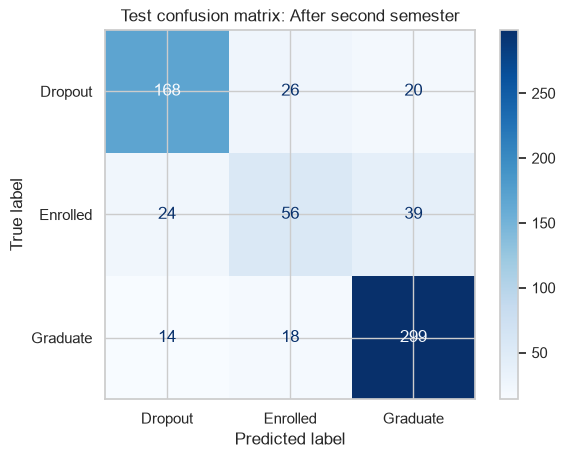

In [21]:
ConfusionMatrixDisplay.from_predictions(
    test_df["target"],
    selected_test_prediction,
    labels=CLASS_ORDER,
    display_labels=CLASS_ORDER,
    cmap="Blues"
)

plt.title(
    f"Test confusion matrix: {selected_stage}"
)
plt.show()

## Final multiclass results

On the independent test set, the selected second-semester model achieved:

- Accuracy: **0.7877**
- Balanced accuracy: **0.7197**
- Macro F1-score: **0.7264**
- Weighted F1-score: **0.7821**
- Macro ROC-AUC: **0.9027**
- Log loss: **0.5314**
- Multiclass Brier score: **0.2998**

The class-prior baseline achieved only **0.4985 accuracy**, **0.3333 balanced accuracy**, and **0.2218 macro F1**. The selected model improved accuracy by **28.92 percentage points** and macro F1 by **0.5046**, demonstrating that it learned useful patterns beyond simply predicting the largest class.

### Per-class results

- Dropout precision: **0.8155**
- Dropout recall: **0.7850**
- Dropout F1: **0.8000**
- Enrolled precision: **0.5600**
- Enrolled recall: **0.4706**
- Enrolled F1: **0.5114**
- Graduate precision: **0.8352**
- Graduate recall: **0.9033**
- Graduate F1: **0.8679**

The easiest class to identify was **Graduate**, with an F1-score of **0.8679** and recall of **0.9033**. The most difficult class was **Enrolled**, with an F1-score of **0.5114** and recall of **0.4706**.

Of the 119 actually Enrolled students, only 56 were identified correctly. The most common individual error was predicting **Graduate for an Enrolled student**, which occurred 39 times. A further 24 Enrolled students were predicted as Dropout.

The confusion matrix also shows that the model correctly identified **168 of 214 Dropouts** and **299 of 331 Graduates**. Therefore, its overall accuracy is strong, but performance is not equally strong across all three classes.

## 3. Selective classification

Ordinary classification forces the model to predict an outcome for every student.

Selective classification introduces a review option:

- If confidence is above a threshold, retain the model prediction.
- If confidence is below the threshold, defer the case for human review.

The confidence threshold is selected using only the validation set.

The objective is to achieve at least 85% accuracy among automatically handled cases while retaining the greatest possible coverage.

In [22]:
validation_output = validation_outputs[
    selected_stage
]

validation_prediction = (
    validation_output["prediction"]
)

validation_probability = (
    validation_output["probability"]
)

validation_confidence = (
    validation_probability.max(axis=1)
)

threshold_rows = []

for threshold in np.arange(
    0.34,
    0.96,
    0.01
):
    accepted = (
        validation_confidence
        >= threshold
    )

    if accepted.sum() < 30:
        continue

    threshold_rows.append({
        "threshold": threshold,
        "coverage": accepted.mean(),
        "accepted_students":
            accepted.sum(),
        "selective_accuracy":
            accuracy_score(
                validation_df.loc[
                    accepted,
                    "target"
                ],
                validation_prediction[
                    accepted
                ]
            ),
        "selective_macro_F1":
            f1_score(
                validation_df.loc[
                    accepted,
                    "target"
                ],
                validation_prediction[
                    accepted
                ],
                labels=CLASS_ORDER,
                average="macro",
                zero_division=0
            )
    })

threshold_results = pd.DataFrame(
    threshold_rows
)

threshold_results.round(4)

,threshold,coverage,accepted_students,selective_accuracy,selective_macro_F1
0,0.34,1.0000,664,0.7545,0.6904
1,0.35,1.0000,664,0.7545,0.6904
2,0.36,0.9985,663,0.7557,0.6914
3,0.37,0.9985,663,0.7557,0.6914
4,0.38,0.9985,663,0.7557,0.6914
...,...,...,...,...,...
57,0.91,0.4488,298,0.9228,0.6670
58,0.92,0.4217,280,0.9357,0.6332
59,0.93,0.3931,261,0.9425,0.6373
60,0.94,0.3810,253,0.9447,0.6395


In [23]:
TARGET_SELECTIVE_ACCURACY = 0.85

eligible_thresholds = threshold_results[
    threshold_results[
        "selective_accuracy"
    ] >= TARGET_SELECTIVE_ACCURACY
]

if len(eligible_thresholds) > 0:
    selected_threshold_row = (
        eligible_thresholds
        .sort_values(
            "coverage",
            ascending=False
        )
        .iloc[0]
    )
else:
    selected_threshold_row = (
        threshold_results
        .sort_values(
            [
                "selective_accuracy",
                "coverage"
            ],
            ascending=False
        )
        .iloc[0]
    )

selected_threshold = (
    selected_threshold_row["threshold"]
)

selected_threshold_row.round(4)

threshold               0.7300
coverage                0.6943
accepted_students     461.0000
selective_accuracy      0.8525
selective_macro_F1      0.7302
Name: 39, dtype: float64

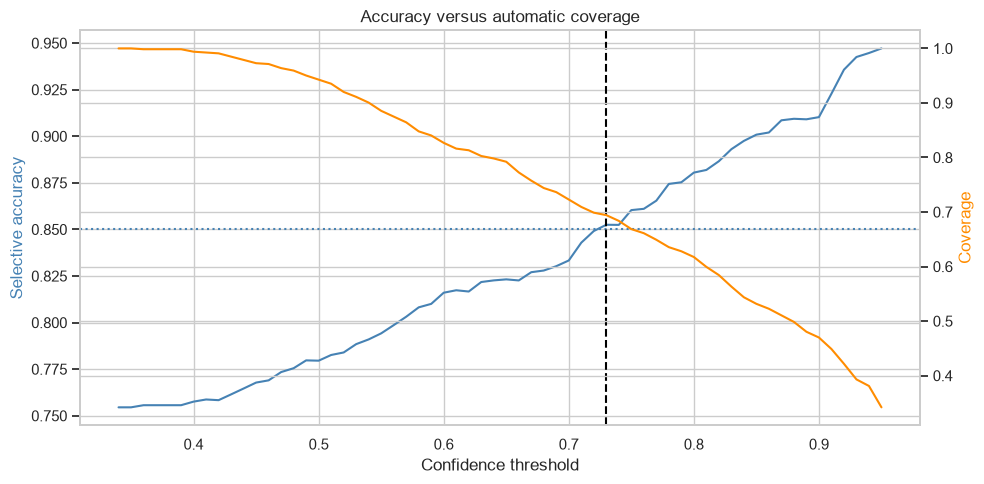

In [24]:
fig, ax1 = plt.subplots(
    figsize=(10, 5)
)

ax1.plot(
    threshold_results["threshold"],
    threshold_results["selective_accuracy"],
    color="steelblue",
    label="Selective accuracy"
)

ax1.axhline(
    TARGET_SELECTIVE_ACCURACY,
    color="steelblue",
    linestyle=":"
)

ax1.set_xlabel("Confidence threshold")
ax1.set_ylabel(
    "Selective accuracy",
    color="steelblue"
)

ax2 = ax1.twinx()

ax2.plot(
    threshold_results["threshold"],
    threshold_results["coverage"],
    color="darkorange",
    label="Coverage"
)

ax2.set_ylabel(
    "Coverage",
    color="darkorange"
)

ax1.axvline(
    selected_threshold,
    color="black",
    linestyle="--",
    label=f"Selected: {selected_threshold:.2f}"
)

plt.title(
    "Accuracy versus automatic coverage"
)
plt.tight_layout()
plt.show()

In [25]:
test_confidence = (
    selected_test_probability.max(axis=1)
)

accepted_test = (
    test_confidence
    >= selected_threshold
)

deferred_test = ~accepted_test

all_test_errors = (
    selected_test_prediction
    != np.asarray(test_df["target"])
)

deferred_errors = (
    all_test_errors
    & deferred_test
)

selective_summary = pd.Series({
    "selected_threshold":
        selected_threshold,
    "automatic_coverage":
        accepted_test.mean(),
    "accepted_students":
        accepted_test.sum(),
    "deferred_students":
        deferred_test.sum(),
    "overall_accuracy":
        accuracy_score(
            test_df["target"],
            selected_test_prediction
        ),
    "accepted_accuracy":
        accuracy_score(
            test_df.loc[
                accepted_test,
                "target"
            ],
            selected_test_prediction[
                accepted_test
            ]
        ),
    "accepted_macro_F1":
        f1_score(
            test_df.loc[
                accepted_test,
                "target"
            ],
            selected_test_prediction[
                accepted_test
            ],
            labels=CLASS_ORDER,
            average="macro",
            zero_division=0
        ),
    "all_model_errors":
        all_test_errors.sum(),
    "errors_in_deferred_group":
        deferred_errors.sum(),
    "fraction_of_errors_deferred":
        (
            deferred_errors.sum()
            / all_test_errors.sum()
        )
})

selective_summary.round(4)

selected_threshold               0.7300
automatic_coverage               0.7093
accepted_students              471.0000
deferred_students              193.0000
overall_accuracy                 0.7877
accepted_accuracy                0.8875
accepted_macro_F1                0.7903
all_model_errors               141.0000
errors_in_deferred_group        88.0000
fraction_of_errors_deferred      0.6241
dtype: float64

In [26]:
deferred_distribution = (
    test_df.loc[
        deferred_test,
        "target"
    ]
    .value_counts()
    .reindex(
        CLASS_ORDER,
        fill_value=0
    )
    .to_frame("deferred_students")
)

deferred_distribution["percentage"] = (
    100
    * deferred_distribution[
        "deferred_students"
    ]
    / deferred_distribution[
        "deferred_students"
    ].sum()
)

deferred_distribution.round(2)

,deferred_students,percentage
target,,
Dropout,53,27.46
Enrolled,65,33.68
Graduate,75,38.86


## Selective classification results

The confidence threshold was selected using the validation set and then applied unchanged to the test set.

- Selected confidence threshold: **0.73**
- Automatic coverage: **0.7093 (70.93%)**
- Automatically classified students: **471**
- Deferred students: **193**
- Deferred proportion: **29.07%**
- Overall accuracy without deferral: **0.7877**
- Accuracy among accepted cases: **0.8875**
- Macro F1 among accepted cases: **0.7903**
- Total model errors: **141**
- Errors contained in the deferred group: **88**
- Fraction of all errors deferred: **0.6241 (62.41%)**

Increasing the confidence threshold improved the reliability of the retained predictions but reduced automatic coverage. In other words, the model became more accurate by sending more uncertain cases for human review.

The selected threshold achieved **85.25% validation accuracy at 69.43% coverage**, satisfying the target of at least 85% selective accuracy. On the independent test set, accepted predictions achieved an even higher accuracy of **88.75%** while retaining **70.93%** of students.

The 193 deferred students consisted of:

- Dropout: **53 students (27.46%)**
- Enrolled: **65 students (33.68%)**
- Graduate: **75 students (38.86%)**

Enrolled students made up only about 18% of the complete dataset but approximately 34% of the deferred group. This is consistent with the earlier finding that Enrolled was the model's most difficult class.

The deferral system concentrated **62.41% of all model errors into 29.07% of the test cases**. This shows that confidence was useful for identifying risky predictions. However, reviewing almost three out of every ten students could still require substantial institutional resources.

In [27]:
def subgroup_diagnostics(
    feature,
    minimum_size=30
):
    rows = []

    for group_value in sorted(
        test_df[feature].unique()
    ):
        group_mask = (
            test_df[feature]
            == group_value
        )

        if group_mask.sum() < minimum_size:
            continue

        actual = test_df.loc[
            group_mask,
            "target"
        ]

        prediction = (
            selected_test_prediction[
                group_mask
            ]
        )

        dropout_mask = (
            actual == "Dropout"
        )

        dropout_recall = (
            np.mean(
                prediction[dropout_mask]
                == "Dropout"
            )
            if dropout_mask.sum() > 0
            else np.nan
        )

        rows.append({
            "feature": feature,
            "group": group_value,
            "observations":
                group_mask.sum(),
            "accuracy":
                accuracy_score(
                    actual,
                    prediction
                ),
            "balanced_accuracy":
                balanced_accuracy_score(
                    actual,
                    prediction
                ),
            "dropout_recall":
                dropout_recall,
            "mean_confidence":
                test_confidence[
                    group_mask
                ].mean(),
            "defer_rate":
                deferred_test[
                    group_mask
                ].mean()
        })

    return pd.DataFrame(rows)

In [28]:
subgroup_results = pd.concat([
    subgroup_diagnostics("gender"),
    subgroup_diagnostics("international"),
    subgroup_diagnostics(
        "scholarship_holder"
    ),
    subgroup_diagnostics(
        "tuition_fees_up_to_date"
    )
], ignore_index=True)

subgroup_results.round(4)

,feature,group,observations,accuracy,balanced_accuracy,dropout_recall,mean_confidence,defer_rate
0,gender,0,420,0.8119,0.7270,0.7857,0.8423,0.2500
1,gender,1,244,0.7459,0.7018,0.7845,0.8117,0.3607
2,international,0,647,0.7836,0.7139,0.7799,0.8304,0.2921
3,scholarship_holder,0,501,0.7665,0.7203,0.7861,0.8173,0.3273
4,scholarship_holder,1,163,0.8528,0.6857,0.7692,0.8736,0.1779
5,tuition_fees_up_to_date,0,82,0.8537,0.5102,0.9306,0.9217,0.1098
6,tuition_fees_up_to_date,1,582,0.7784,0.6997,0.7113,0.8183,0.3162


In [29]:
importance = permutation_importance(
    selected_model,
    test_df[selected_features],
    test_df["target"],
    scoring="f1_macro",
    n_repeats=15,
    random_state=SEED,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance":
        importance.importances_mean,
    "importance_sd":
        importance.importances_std
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(15).round(4)

,feature,importance,importance_sd
37,second_sem_approval_rate,0.0991,0.0140
16,tuition_fees_up_to_date,0.0459,0.0057
30,first_sem_approval_rate,0.0329,0.0103
19,age_at_enrollment,0.0192,0.0077
3,course,0.0142,0.0091
33,curricular_units_2nd_sem_evaluations,0.0139,0.0091
34,curricular_units_2nd_sem_approved,0.0131,0.0095
32,curricular_units_2nd_sem_enrolled,0.0094,0.0044
35,curricular_units_2nd_sem_grade,0.0094,0.0053
10,mother_s_occupation,0.0090,0.0088


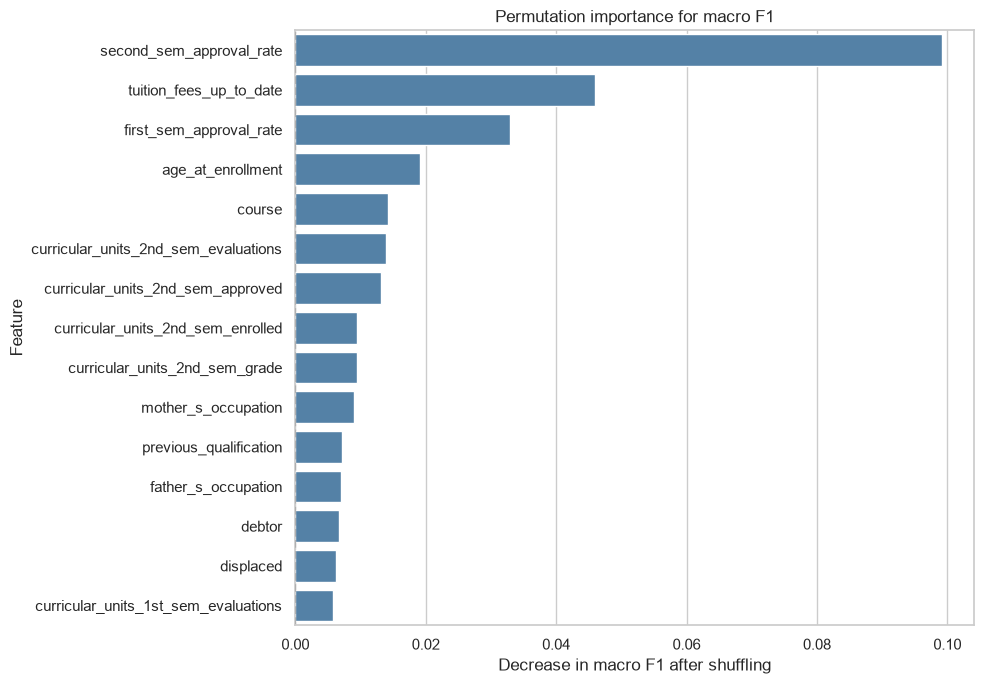

In [30]:
top_importance = importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_importance,
    x="importance",
    y="feature",
    color="steelblue"
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Permutation importance for macro F1"
)
plt.xlabel(
    "Decrease in macro F1 after shuffling"
)
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature importance and subgroup diagnostics

The most influential predictor was **second-semester approval rate**. Shuffling this feature reduced macro F1 by approximately **0.0991**, considerably more than any other predictor.

The next most important predictors were:

1. Tuition fees up to date: **0.0459**
2. First-semester approval rate: **0.0329**
3. Age at enrollment: **0.0192**
4. Course: **0.0142**
5. Second-semester evaluations: **0.0139**

These results explain why the second-semester model performed best: the engineered second-semester approval rate was the strongest predictor in the final model. Permutation importance measures predictive usefulness, however, and must not be interpreted as evidence that these features cause a particular student outcome.

Subgroup results showed some performance differences. Accuracy was **0.8119** for gender group 0 and **0.7459** for gender group 1. Group 1 also had a higher deferral rate: **36.07% compared with 25.00%**. The meaning of the numeric gender codes should be checked in the dataset documentation before naming these groups.

Scholarship holders had higher raw accuracy than non-holders (**0.8528 versus 0.7665**) but slightly lower balanced accuracy (**0.6857 versus 0.7203**). This illustrates why raw accuracy should not be used by itself when subgroup class distributions differ.

Students whose tuition fees were not current had **0.8537 accuracy** but only **0.5102 balanced accuracy**. Their high raw accuracy is partly explained by the strong concentration of Dropout outcomes in this group, so it does not mean the model performed equally well across all three classes.

The international-student subgroup contained fewer than 30 test observations and was excluded by the diagnostic function. Its performance therefore cannot be evaluated reliably from this test split.

Overall, the model is useful as an early-support screening tool, particularly when uncertainty-based deferral is included. It should not be used to deny admission, scholarships, or educational opportunities. Predictions should trigger supportive human review, and subgroup performance should continue to be monitored.